# Assignment 2 — Shallow Models Training, Validation, and Tuning

**Neera Patel**  
AI & Machine Learning Foundations  

GitHub Repository: https://github.com/neerapatel5/ML-fundamentals-2026/blob/main/Assignment_2_Neera_Patel.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import warnings
warnings.filterwarnings("ignore")

# Loading the Dataset + EDA

For this assignment, I am using the `hour.csv` dataset from the UCI Bike Sharing Dataset. The goal is to predict hourly bike rental demand (`cnt`) using environmental, weather, and temporal variables.

Since this is ultimately a regression problem, the first thing I want to understand is how the target variable behaves before touching any models. A lot of the ML foundations lectures emphasized that good modeling decisions usually start with understanding the structure of the data itself rather than immediately jumping into training.

In [2]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Before exploring relationships between variables, I want to inspect the overall structure of the dataset:

- number of observations
- feature types
- missing values
- whether any columns immediately look suspicious or redundant

One thing I learned from Assignment 1 is that catching leakage or redundant variables early can save a lot of downstream issues later in the pipeline.

In [3]:
## examine dataset
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(17379, 17)

Column Names:
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Data Types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [4]:
## check for missing values
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Even though there are no explicit missing values, I still want to stay cautious about “hidden” data quality issues.

In [5]:
df.describe

<bound method NDFrame.describe of        instant      dteday  season  yr  mnth  hr  holiday  weekday  \
0            1  2011-01-01       1   0     1   0        0        6   
1            2  2011-01-01       1   0     1   1        0        6   
2            3  2011-01-01       1   0     1   2        0        6   
3            4  2011-01-01       1   0     1   3        0        6   
4            5  2011-01-01       1   0     1   4        0        6   
...        ...         ...     ...  ..   ...  ..      ...      ...   
17374    17375  2012-12-31       1   1    12  19        0        1   
17375    17376  2012-12-31       1   1    12  20        0        1   
17376    17377  2012-12-31       1   1    12  21        0        1   
17377    17378  2012-12-31       1   1    12  22        0        1   
17378    17379  2012-12-31       1   1    12  23        0        1   

       workingday  weathersit  temp   atemp   hum  windspeed  casual  \
0               0           1  0.24  0.2879  0.81    

- `cnt` appears highly variable, which definitely makes sense because bike demand probably changes dramatically depending on hour, weather, and season.
- `casual` and `registered` are likely leakage-related variables because they directly sum into the target variable `cnt`.

From a predictive modeling perspective, including features that are mathematically tied to the target would artificially inflate performance and affect real-world generalization.

### Exploring the Target Variable (`cnt`)

The target variable is the hourly count of rented bikes.

Before building regression models, I want to examine:
- distribution shape
- skewness
- possible outliers
- whether transformations may eventually help performance

If the target distribution is heavily skewed or contains extreme values, some models may struggle more than others.

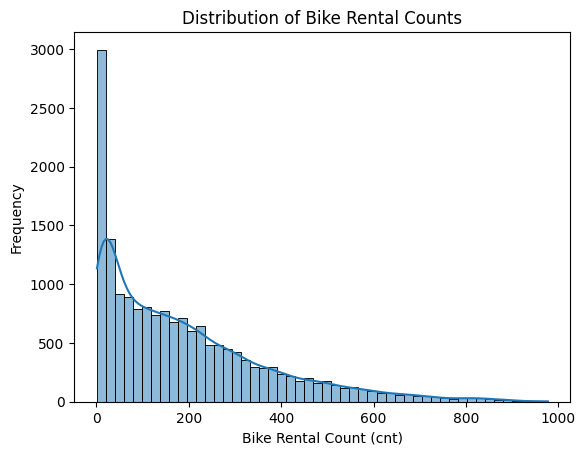

Skewness of cnt:
1.2774116037490577


In [6]:
sns.histplot(df["cnt"], bins=50, kde=True)

plt.title("Distribution of Bike Rental Counts")
plt.xlabel("Bike Rental Count (cnt)")
plt.ylabel("Frequency")

plt.show()

print("Skewness of cnt:")
print(df["cnt"].skew())

The distribution is clearly right-skewed, meaning there are many lower-rental hours and fewer extremely high-demand hours, which adds up. Most hours during the day probably experience moderate demand, while commuting periods or ideal weather conditions create those sharp spikes.

The skewness is important because:
- Linear Regression may struggle with nonlinear spikes in demand
- Tree-based models like Random Forest and Gradient Boosting may adapt better to these irregular patterns
- Residual variance may increase at higher prediction values, which could later indicate heteroskedasticity

### Numerical Feature Relationships

Before feature engineering, I also want to examine relationships between continuous variables. This is especially important because highly correlated predictors can reduce interpretability or destabilize linear models. Tree-based models are usually more tolerant of multicollinearity, but linear models are much more sensitive to it.

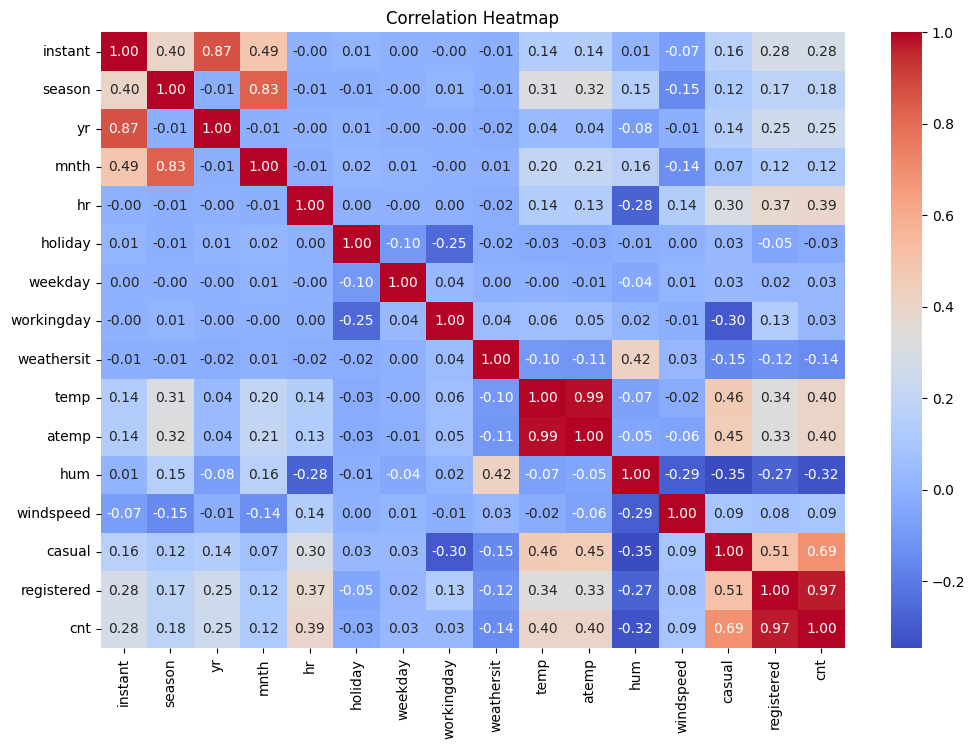

In [7]:
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

A few relationships stand out immediately. `registered` (~0.97) and `casual` (~0.69) are both highly correlated with `cnt`, which makes sense since `cnt = casual + registered`. Because of this, both columns create target leakage and will be removed before modeling.

`temp` and `atemp` are also almost perfectly correlated (~0.99), so keeping both may introduce unnecessary redundancy. Meanwhile, variables like `hr`, `temp`, and `hum` show more moderate relationships with `cnt`, suggesting that nonlinear patterns and feature interactions may matter more than simple linear correlation alone.

Applying what I have learned in class, correlation alone does not necessarily measure predictive usefulness, especially for nonlinear models. Some variables may appear weak in isolation but become highly important once interactions and nonlinear splits are introduced in models like Random Forests or Gradient Boosting.

### Temporal Patterns (Hour of Day)

One of the most important variables in this dataset is likely `hr`. Naturally, human behavior tends to follow cyclical patterns rather than purely linear ones. Commute hours, lunch breaks, and nighttime inactivity should all create predictable fluctuations in bike rentals.

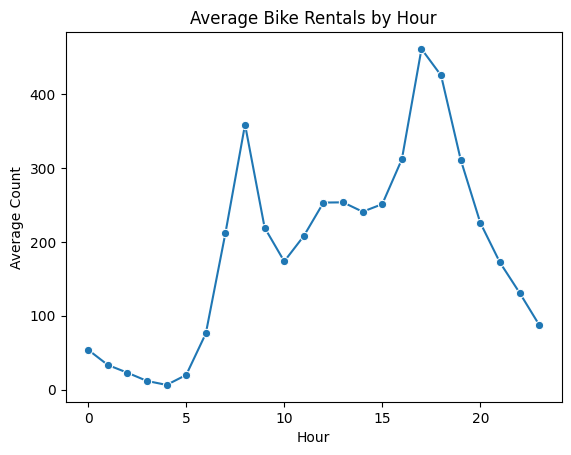

In [8]:
hourly_avg = df.groupby("hr")["cnt"].mean()

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker="o"
)

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Count")

plt.show()

The pattern is extremely intuitive, showing strong peaks during commuting hours and lower activity overnight. This suggests that temporal structure is going to be very important for prediction performance. It also reinforces why cyclical encoding is preferable over raw integer encoding for variables like `hr` and `weekday`.

### Weather and Environmental Effects

Since this is a transportation-related prediction problem, weather likely plays a major role in rental demand.
- warmer temperatures → more rentals
- extreme humidity → fewer rentals

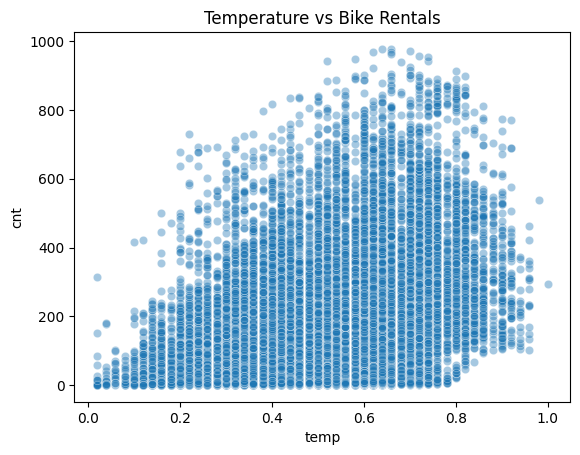

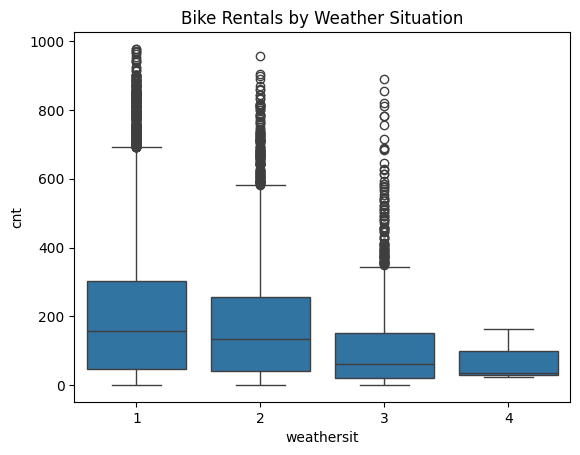

In [9]:
sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    alpha=0.4
)
plt.title("Temperature vs Bike Rentals")
plt.show()

sns.boxplot(
    data=df,
    x="weathersit",
    y="cnt"
)
plt.title("Bike Rentals by Weather Situation")
plt.show()

Bike rentals generally increase as temperature rises, although the relationship is not perfectly linear. The weather condition boxplot also shows a clear decline in rentals during worse weather conditions, especially in categories 3 and 4. Together, these plots clearly show that environmental variables will play a meaningful role in prediction performance.

### Outliers and Suspicious Patterns

At this stage, I want to identify whether any observations appear extreme enough to distort modeling performance. I want to actually understand whether they reflect actual behavior or data errors before immediately just removing outliers. In transportation datasets, unusually high demand periods may actually contain important business information rather than noise.

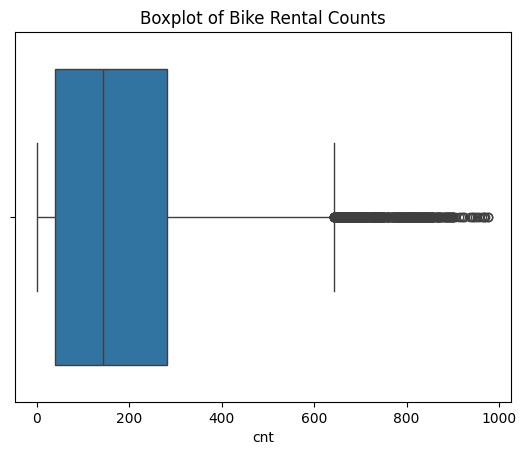

In [10]:
sns.boxplot(x=df["cnt"])
plt.title("Boxplot of Bike Rental Counts")
plt.show()

The boxplot shows several high-demand outliers, particularly above 600 rentals. That being said, these values likely represent real peak commuting or seasonal demand rather than data errors, so I do not plan to remove them as of right now. Since tree-based models are generally better equipped to handle outliers, keeping these observations may help the model better capture real-world spikes in bike usage.

I considered removing high-demand outliers, but decided against it after revisiting the problem context. Removing them could make the model perform worse during important peak-demand periods. Instead of deleting those observations, I relied on tree-based models to better handle the nonlinear behavior.

### Planned Feature Removal

Based on the EDA, I plan to remove the following columns before modeling:
instant: identifier only
dteday: raw date column not directly useful in current form 
casual: leakage into target
registered: Leakage into target 

# Data Splitting
Since this dataset is time-based, I am using a random split with a fixed seed because the data covers repeated hourly patterns across two years, and I want all three sets to contain a realistic mix of seasons, hours, and weather conditions.

In [11]:
columns_drop = ["instant", "dteday", "casual", "registered"]

bike_model = df.drop(columns=columns_drop).copy()

## separate features from the prediction target
X = bike_model.drop(columns="cnt")
y = bike_model["cnt"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (17379, 12)
Target shape: (17379,)


In [12]:
## first split: 60% training data, 40% held out for validation/test
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=2026,
    shuffle=True
)

# second split: Split the 40% into 20% validation and 20% test

X_val, X_test, y_val, y_test = train_test_split(
    X_holdout,
    y_holdout,
    test_size=0.50,
    random_state=2026,
    shuffle=True
)

In [13]:
## check final split sizes to ensure they're right

split_summary = pd.DataFrame({
    "Set": ["Training", "Validation", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Percent of Total": [
        len(X_train) / len(df) * 100,
        len(X_val) / len(df) * 100,
        len(X_test) / len(df) * 100
    ],
    "Target Mean": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ],
    "Target Std": [
        y_train.std(),
        y_val.std(),
        y_test.std()
    ]
})

split_summary

,Set,Rows,Percent of Total,Target Mean,Target Std
0,Training,10427,59.997698,188.571497,180.004924
1,Validation,3476,20.001151,183.850403,180.432694
2,Test,3476,20.001151,197.750288,186.178722


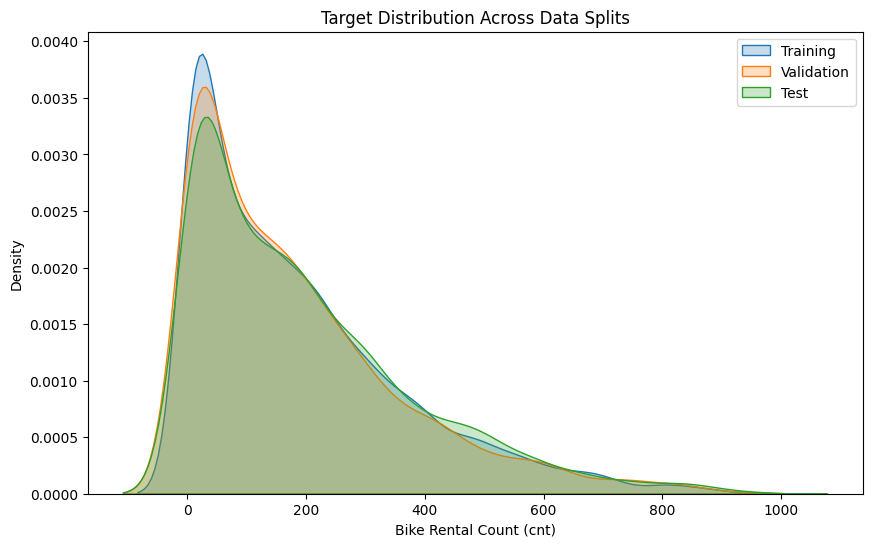

In [14]:
## check that the target distribution is reasonably similar across splits
plt.figure(figsize=(10, 6))

sns.kdeplot(y_train, label="Training", fill=True, alpha=0.25)
sns.kdeplot(y_val, label="Validation", fill=True, alpha=0.25)
sns.kdeplot(y_test, label="Test", fill=True, alpha=0.25)

plt.title("Target Distribution Across Data Splits")
plt.xlabel("Bike Rental Count (cnt)")
plt.ylabel("Density")
plt.legend()
plt.show()

The final split follows the required 60/20/20 structure. The distributions are not identical, but they are close enough to support fair validation and testing. Most importantly, this split happens before scaling, encoding, cyclical transformations, or interaction terms, so the validation and test sets remain genuinely unseen.

I used a 60/20/20 split to balance training size with reliable evaluation. The training set is large enough for the models to learn meaningful patterns, while keeping separate validation and test sets allows me to tune hyperparameters and evaluate final generalization performance without reusing the same data multiple times.

# Feature Engineering

At this stage, I want to transform the data into a format that better reflects the actual structure of the problem rather than simply feeding raw variables into the models. Based on the EDA:
- `hr` and `weekday` behave cyclically rather than linearly
- `temp` and `atemp` are almost perfectly correlated
- weather and environmental variables likely interact with one another
- scaling is important for Linear Regression performance and consistency

One major issue in my previous assignment was accidentally breaking the feature pipeline and losing variables after encoding/scaling. To avoid that this time, I want all transformations to flow into one final feature matrix.

In [15]:
## copy datasets
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

### Cyclical Encoding
Variables like hour and weekday are cyclical. Using sine/cosine transformations preserves this circular (daily) structure much better than raw integer encoding.

In [16]:
## cyclical encoding for hour
for dataset in [X_train_fe, X_val_fe, X_test_fe]:

    dataset["hr_sin"] = np.sin(2 * np.pi * dataset["hr"] / 24)
    dataset["hr_cos"] = np.cos(2 * np.pi * dataset["hr"] / 24)

## cyclical encoding for weekday
for dataset in [X_train_fe, X_val_fe, X_test_fe]:

    dataset["weekday_sin"] = np.sin(2 * np.pi * dataset["weekday"] / 7)
    dataset["weekday_cos"] = np.cos(2 * np.pi * dataset["weekday"] / 7)

In [17]:
## no longer need original cyclical columns
X_train_fe.drop(columns=["hr", "weekday"], inplace=True)
X_val_fe.drop(columns=["hr", "weekday"], inplace=True)
X_test_fe.drop(columns=["hr", "weekday"], inplace=True)

Although sine/cosine features are already bounded between -1 and 1, I kept them within the standardized preprocessing pipeline to maintain consistency across all continuous variables.

### Removing Redundant Features
The correlation heatmap showed that `temp` and `atemp` have an almost perfect correlation (~0.99). Keeping both would add redundancy without contributing much additional information. To reduce multicollinearity and simplify the feature space, I am removing `atemp`.

In [18]:
## drop atemp
X_train_fe.drop(columns=["atemp"], inplace=True)
X_val_fe.drop(columns=["atemp"], inplace=True)
X_test_fe.drop(columns=["atemp"], inplace=True)

### Interaction Feature

From the EDA, temperature and humidity both have relation to bike demand. However, their effects may not operate independently.
For example, warm weather may increase rentals unless the humidity becomes too high. To capture this possibility, I am adding a simple interaction term between temperature and humidity.

In [19]:
# temperature & humidity 

for dataset in [X_train_fe, X_val_fe, X_test_fe]:

    dataset["temp_hum_interaction"] = (
        dataset["temp"] * dataset["hum"]
    )

In [20]:
X_train["windspeed_hum_interaction"] = X_train["windspeed"] * X_train["hum"]
X_val["windspeed_hum_interaction"] = X_val["windspeed"] * X_val["hum"]
X_test["windspeed_hum_interaction"] = X_test["windspeed"] * X_test["hum"]

In [21]:
## define feature groups 
categorical_features = [
    "season",
    "weathersit",
    "mnth"
]

numerical_features = [
    "temp",
    "hum",
    "windspeed",
    "temp_hum_interaction",
    "hr_sin",
    "hr_cos",
    "weekday_sin",
    "weekday_cos"
]

### Encoding and Scaling
At this point, categorical variables will be **one-hot encoded** and continuous variables will be **standardized**. Most importantly, the preprocessing objects are fit ONLY on the training data. The validation and test sets are transformed using those same fitted parameters to prevent leakage.

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [23]:
## fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train_fe)

## apply learned transformations
X_val_processed = preprocessor.transform(X_val_fe)
X_test_processed = preprocessor.transform(X_test_fe)

In [24]:
print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Training shape: (10427, 25)
Validation shape: (3476, 25)
Test shape: (3476, 25)


The preprocessing pipeline now combines cyclical encoding, interaction features, scaling, and one-hot encoding into one consistent feature matrix. Unlike the previous assignment, the numerical and categorical features remain unified throughout preprocessing, which prevents downstream pipeline errors and ensures all models train on the complete feature set. All three processed datasets contain the same feature structure, confirming that the preprocessing pipeline was applied consistently across training, validation, and test data.

In [25]:
encoded_feature_names = preprocessor.named_transformers_[
    "cat"
].get_feature_names_out(categorical_features)

all_feature_names = (
    numerical_features +
    list(encoded_feature_names)
)

# Convert arrays back into DataFrames
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=all_feature_names
)

X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=all_feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=all_feature_names
)

Converting the processed arrays back into DataFrames allows the transformed feature names to remain interpretable throughout the modeling process. This will be especially useful later when analyzing feature importance, debugging model behavior, and comparing which variables contribute most strongly across different algorithms.

# Baseline Model: Linear Regression

I am starting with Linear Regression as a baseline model because it provides a simple and highly interpretable reference point before moving into more complex nonlinear methods.
Although bike rental demand likely contains nonlinear relationships and interactions, Linear Regression is still useful because:
- it establishes a performance benchmark
- it helps evaluate whether more complex models are actually improving generalization
- it is sensitive to feature scaling and multicollinearity, making it a good test of the preprocessing pipeline

In [26]:
## train LR model
lin_reg = LinearRegression()

lin_reg.fit(X_train_processed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
## predict
lin_train_pred = lin_reg.predict(X_train_processed)
lin_val_pred = lin_reg.predict(X_val_processed)

In [28]:
## training metrics
lin_train_mse = mean_squared_error(y_train, lin_train_pred)
lin_train_mae = mean_absolute_error(y_train, lin_train_pred)
lin_train_r2 = r2_score(y_train, lin_train_pred)

## validation metrics 
lin_val_mse = mean_squared_error(y_val, lin_val_pred)
lin_val_mae = mean_absolute_error(y_val, lin_val_pred)
lin_val_r2 = r2_score(y_val, lin_val_pred)

In [29]:
print("Linear Regression Performance")
print("-" * 40)

print("Training Metrics")
print(f"MSE: {lin_train_mse:.2f}")
print(f"MAE: {lin_train_mae:.2f}")
print(f"R²:  {lin_train_r2:.4f}")

print("\nValidation Metrics")
print(f"MSE: {lin_val_mse:.2f}")
print(f"MAE: {lin_val_mae:.2f}")
print(f"R²:  {lin_val_r2:.4f}")

Linear Regression Performance
----------------------------------------
Training Metrics
MSE: 17462.97
MAE: 93.61
R²:  0.4610

Validation Metrics
MSE: 17497.58
MAE: 93.24
R²:  0.4624


The training and validation metrics are very close to one another, which suggests the model is not heavily overfitting. However, the R² score of about 0.46 also shows that a large portion of the variance in bike rental demand is still unexplained. This is not too surprising since Linear Regression may struggle to capture the nonlinear patterns and sharp demand spikes visible during EDA.

In [30]:
##residuals 
lin_residuals = y_val - lin_val_pred

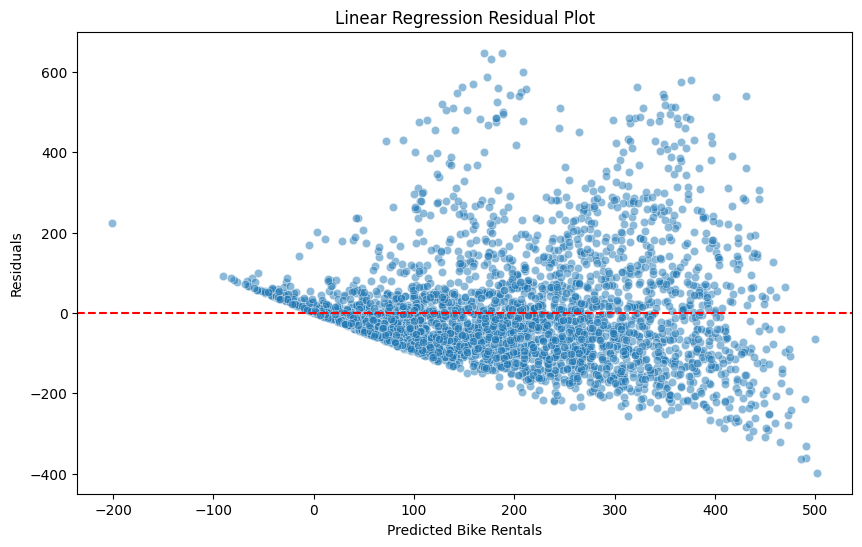

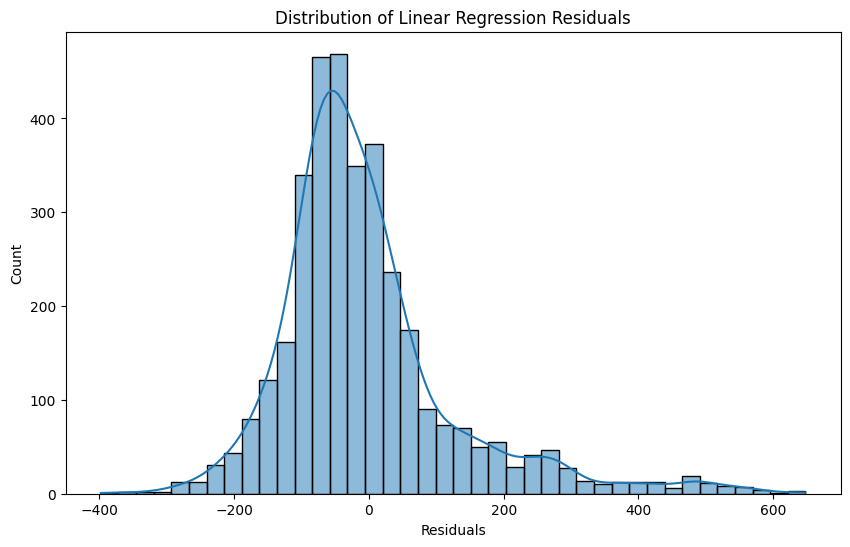

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=lin_val_pred,
    y=lin_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Bike Rentals")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(
    lin_residuals,
    bins=40,
    kde=True
)

plt.xlabel("Residuals")
plt.title("Distribution of Linear Regression Residuals")
plt.show()

The residual plot shows a noticeable funnel shape rather than a completely random spread. As the predicted rental counts increase, the variance of the residuals also increases, suggesting heteroskedasticity and indicating that prediction errors become less stable at higher demand levels. There also appears to be some remaining structure in the residuals, which suggests the model is still missing nonlinear relationships or interaction effects within the data.

The residual distribution is centered roughly around zero, which is a good sign overall. However, the distribution is not perfectly symmetric and contains heavier tails, especially on the positive side. This suggests that the model occasionally underestimates extremely high-demand periods, likely because Linear Regression smooths complex patterns into simpler linear relationships.

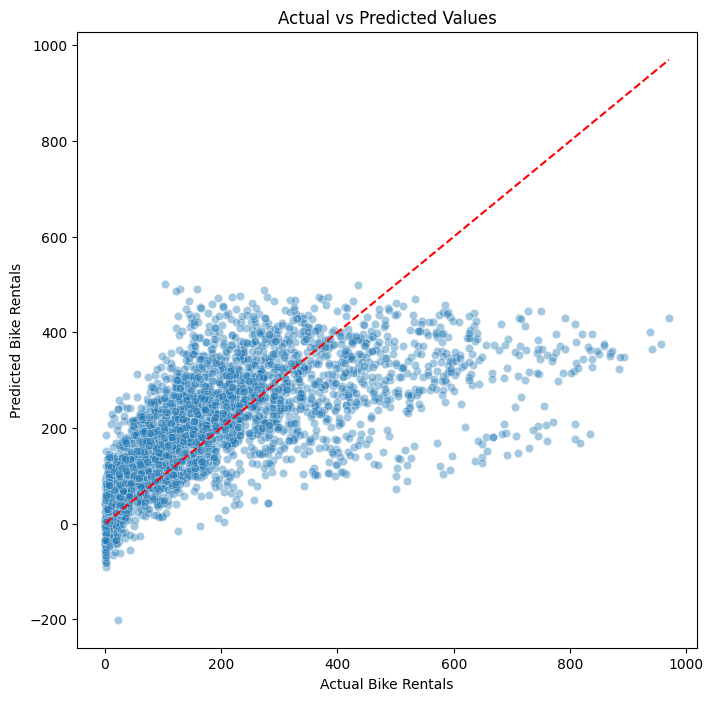

In [32]:
## actual v predicted
plt.figure(figsize=(8,8))
sns.scatterplot(
    x=y_val,
    y=lin_val_pred,
    alpha=0.4
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Values")
plt.show()

The model captures general demand trends reasonably well at lower and moderate rental levels, but performance weakens for larger rental counts. Predicted values become compressed compared to the true values, meaning the model struggles to fully capture peak demand periods. This is another sign of **underfitting** and reinforces the idea that more flexible nonlinear models may perform better on this dataset.

### Bias–Variance Reflection

Overall, the Linear Regression model feels too simple for the structure of this dataset. Bike demand clearly follows cyclical patterns, and factors like weather and commuting behavior probably interact in ways that are not fully linear. Because of that, the model seems to underfit some of the more complex demand spikes.

At the same time, the model is fairly stable since the training and validation performance are very similar. That lower variance is one advantage of simpler models, even if they miss some of the deeper nonlinear patterns. This gives me a solid baseline before moving into more flexible models like Random Forest and Gradient Boosting.

### Iterative Reflection After Baseline Model

The feature engineering choices in this section matter more for LR than they likely will for the tree-based models. Linear Regression is more sensitive to scaling and highly correlated variables, so preprocessing plays a much bigger role in overall performance. Before training the model, I expected the LR model to struggle with peak demand periods because the EDA showed strong cyclical and nonlinear behavior. The cyclical features and interaction term still make sense based on the EDA. The bigger limitation seems to be the model itself. Linear Regression may just be too simple for a dataset with strong seasonal shifts, commuting spikes, and changing weather conditions.

# Random Forest Regressor
The EDA showed strong cyclical behavior, nonlinear weather effects, and sharp demand spikes that Linear Regression struggled to fully model. Random Forest is a good next step because it can:
- model nonlinear patterns naturally
- capture feature interactions without manually specifying them
- reduce overfitting by averaging across many decision trees

In [33]:
## train model 
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
## predict
rf_train_pred = rf_model.predict(X_train_processed)
rf_val_pred = rf_model.predict(X_val_processed)

In [35]:
## training metrics - keeping same across all models
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)

## validation metrics
rf_val_mse = mean_squared_error(y_val, rf_val_pred)
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)

In [36]:
print("Random Forest Performance")
print("-" * 40)

print("Training Metrics")
print(f"MSE: {rf_train_mse:.2f}")
print(f"MAE: {rf_train_mae:.2f}")
print(f"R²:  {rf_train_r2:.4f}")

print("\nValidation Metrics")
print(f"MSE: {rf_val_mse:.2f}")
print(f"MAE: {rf_val_mae:.2f}")
print(f"R²:  {rf_val_r2:.4f}")

Random Forest Performance
----------------------------------------
Training Metrics
MSE: 697.26
MAE: 16.95
R²:  0.9785

Validation Metrics
MSE: 4885.77
MAE: 45.14
R²:  0.8499


The Random Forest model performs much better than the baseline model overall. The validation R² increased to about 0.85, while both MSE and MAE dropped substantially. This tells me the dataset contains a strong nonlinear structure that Linear Regression could not fully capture.

At the same time, the training performance is much stronger than the validation performance. A training R² near 0.98 compared to a validation R² of 0.85 suggests the model is starting to memorize some training patterns. The gap is not extreme, but it could signal that variance is increasing as the model becomes more flexible.

In [37]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Validation MSE": [lin_val_mse, rf_val_mse],
    "Validation MAE": [lin_val_mae, rf_val_mae],
    "Validation R²": [lin_val_r2, rf_val_r2]
})

model_comparison

,Model,Validation MSE,Validation MAE,Validation R²
0,Linear Regression,17497.584629,93.242412,0.462383
1,Random Forest,4885.769327,45.141314,0.849884


The comparison between the two models makes the tradeoff very clear. Linear Regression struggled to capture the cyclical and nonlinear behavior shown during EDA, while Random Forest handled those relationships much more effectively through flexible tree splits and feature interactions. At this stage, the main challenge is balancing complexity with generalization. Random Forest performs significantly better overall, but the growing gap between training and validation performance suggests that tuning will be important to control overfitting moving forward.

In [38]:
rf_residuals = y_val - rf_val_pred

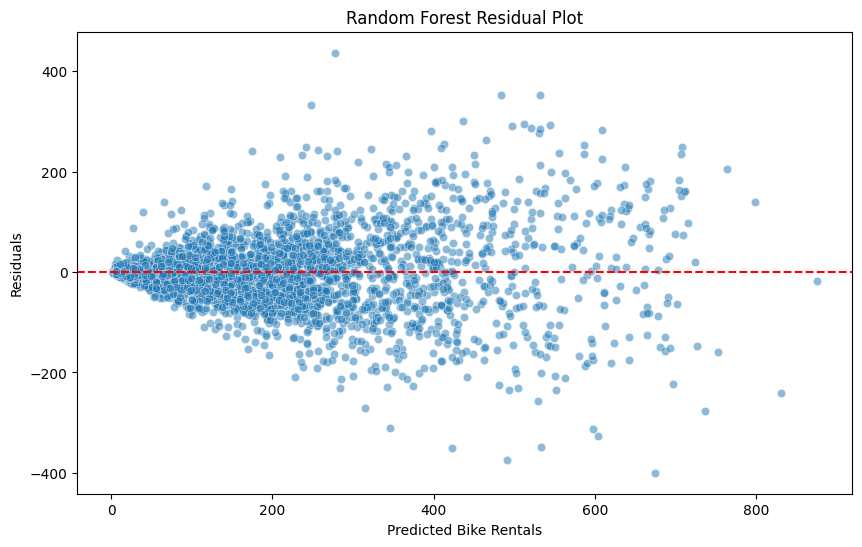

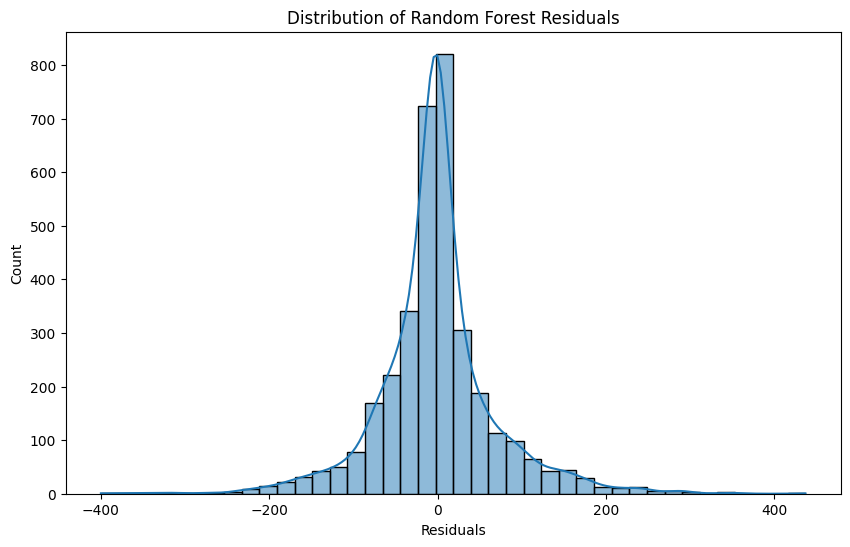

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rf_val_pred,
    y=rf_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Bike Rentals")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

plt.figure(figsize=(10,6))

sns.histplot(
    rf_residuals,
    bins=40,
    kde=True
)

plt.xlabel("Residuals")
plt.title("Distribution of Random Forest Residuals")

plt.show()

The errors now look much more concentrated around zero compared to the Linear Regression residual plot. The large funnel shape from the baseline model is reduced. This suggests Random Forest is handling nonlinear behavior more effectively. There is still some widening of the residual spread at higher prediction values, especially during very high-demand periods. However, the remaining structure is noticeably smaller than before, which proves the model is capturing a much larger portion of the underlying demand patterns.

The residual distribution is now much tighter and more centered around zero compared to the Linear Regression model. Extremely large residuals still exist, but they occur less frequently and the overall spread is smaller. This improvement supports the idea that Random Forest is better at modeling sharp changes in demand. The model still struggles occasionally with extreme rental spikes, but overall prediction stability improved substantially.

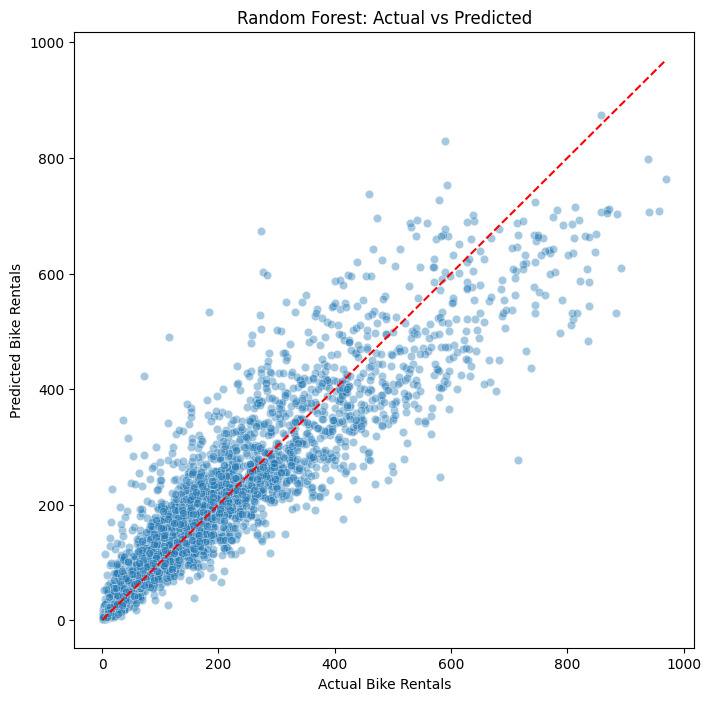

In [40]:
## actual v predicted
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_val,
    y=rf_val_pred,
    alpha=0.4
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

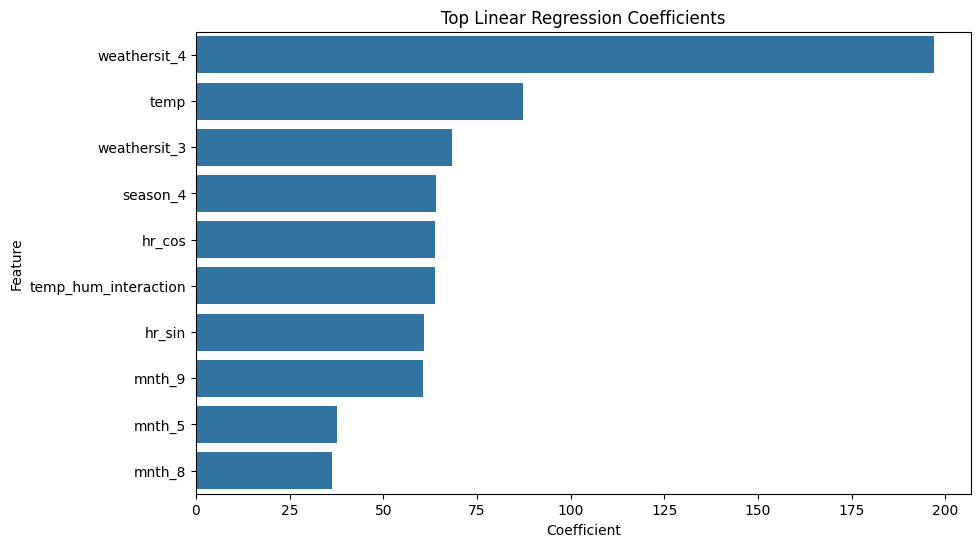

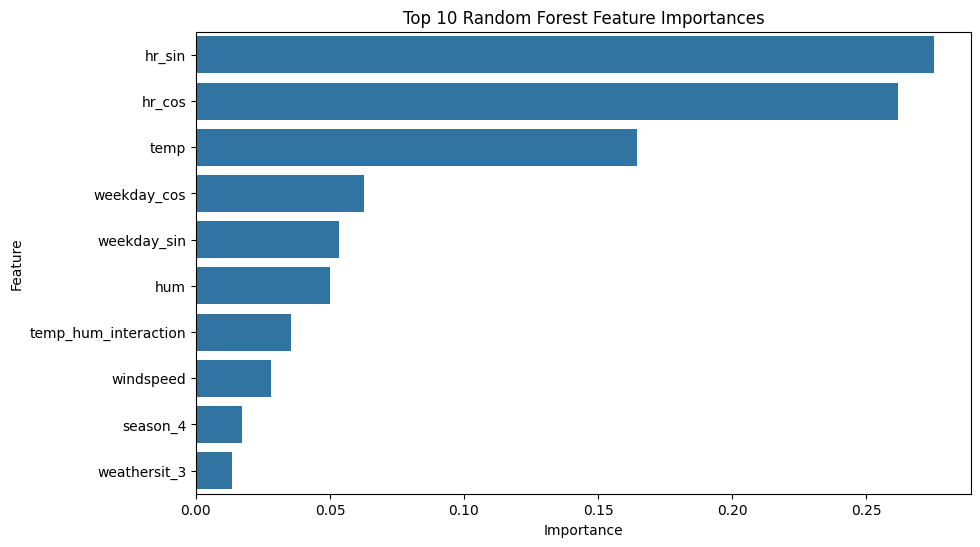

In [41]:
## Feature Importance for LR

lin_coefficients = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": np.abs(lin_reg.coef_)
})

lin_coefficients = lin_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)
lin_coefficients.head(10)
top_lin = lin_coefficients.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_lin,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Linear Regression Coefficients")
plt.show()

## Feature Importance for RF
feature_importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

Comparing the two plots makes the difference between the models much clearer. Linear Regression spreads importance across several seasonal and weather-related variables, while Random Forest relies much more heavily on the cyclical hour features. This suggests the tree-based model is capturing time-based demand patterns much more effectively.

It is also interesting that both models still rank `temp` and the `temp_hum_interaction` feature relatively highly. That gives more support to the feature engineering decisions from earlier in the notebook. The EDA suggested that weather effects were likely interacting with one another, and both models ended up using those features in meaningful ways. This comparison also helps explain why Random Forest performed so much better overall. Instead of forcing relationships into a single linear equation, it can separate the data into more flexible patterns that better reflect commuting behavior and changing rental demand throughout the day.

### Iterative Reflection after Random Forest model
One thing I noticed after training Random Forest is that some preprocessing choices mattered differently than they did for Linear Regression. Scaling likely contributed very little here since tree-based models are not distance-based. That being said, the cyclical encoding still appears extremely useful because the transformed hour variables became the two most important predictors in the model.

At this stage, I do not think I need to revisit the overall preprocessing pipeline yet. The feature importance results and validation performance both suggest that the engineered features are helping rather than hurting performance. The bigger focus moving forward will likely be controlling variance and preventing overfitting during hyperparameter tuning.

# Gradient Boosting Regressor

The Random Forest model already showed that the dataset contains a strong nonlinear structure. However, Random Forest builds trees independently and averages them together, which can sometimes limit how precisely the model corrects difficult prediction errors.

Instead of building trees independently, Gradient Boosting builds them sequentially, where each new tree focuses on correcting the mistakes made by the previous ones. In a real-world setting, this can be especially useful for capturing more subtle demand shifts caused by weather, commuting behavior, and seasonal changes. At this stage, I want to see whether Gradient Boosting can improve validation performance further without causing excessive overfitting.

In [42]:
gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [43]:
## predict
gbr_train_pred = gbr_model.predict(X_train_processed)
gbr_val_pred = gbr_model.predict(X_val_processed)

In [44]:
## training metrics - same all across
gbr_train_mse = mean_squared_error(y_train, gbr_train_pred)
gbr_train_mae = mean_absolute_error(y_train, gbr_train_pred)
gbr_train_r2 = r2_score(y_train, gbr_train_pred)

## validation metrics
gbr_val_mse = mean_squared_error(y_val, gbr_val_pred)
gbr_val_mae = mean_absolute_error(y_val, gbr_val_pred)
gbr_val_r2 = r2_score(y_val, gbr_val_pred)

In [45]:
print("Gradient Boosting Performance")
print("-" * 40)

print("Training Metrics")
print(f"MSE: {gbr_train_mse:.2f}")
print(f"MAE: {gbr_train_mae:.2f}")
print(f"R²:  {gbr_train_r2:.4f}")

print("\nValidation Metrics")
print(f"MSE: {gbr_val_mse:.2f}")
print(f"MAE: {gbr_val_mae:.2f}")
print(f"R²:  {gbr_val_r2:.4f}")

Gradient Boosting Performance
----------------------------------------
Training Metrics
MSE: 7135.76
MAE: 58.59
R²:  0.7798

Validation Metrics
MSE: 7506.14
MAE: 59.84
R²:  0.7694


Gradient Boosting improved substantially over Linear Regression, but it still did not outperform Random Forest on the validation set. The validation R² increased to about 0.77, which confirms that boosting is capturing the nonlinear structure much better than the baseline model. Validation MSE and MAE also dropped significantly compared to Linear Regression.

At the same time, the model still appears to struggle during very high-demand rental periods. This suggests the current boosting setup may still be slightly underfitting some of the more extreme demand spikes.

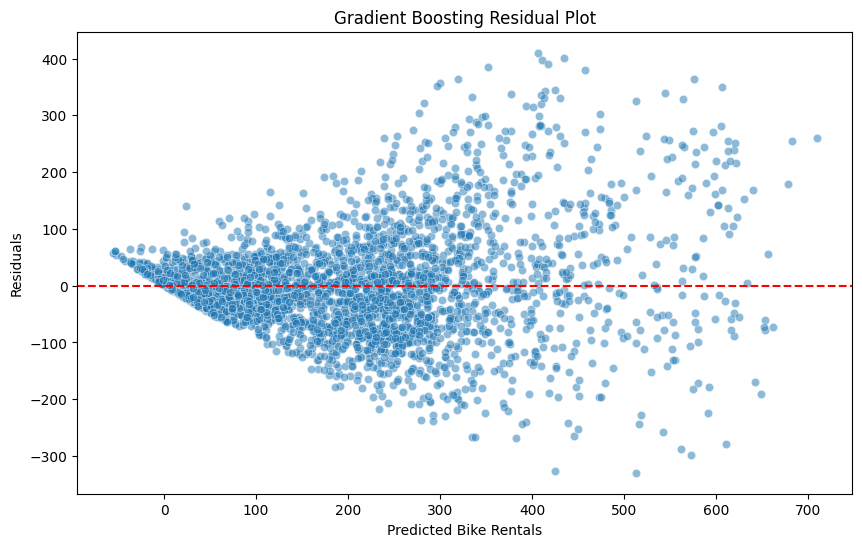

In [46]:
gbr_residuals = y_val - gbr_val_pred

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=gbr_val_pred,
    y=gbr_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Bike Rentals")
plt.ylabel("Residuals")
plt.title("Gradient Boosting Residual Plot")

plt.show()

The residual plot still shows some widening as predicted rental demand increases. The spread is smaller than the Linear Regression model, but the structure is still more noticeable than it was with Random Forest.

This tells me Gradient Boosting captured a large amount of the nonlinear behavior, but not quite as effectively as Random Forest in its current configuration. The model appears more stable than the baseline model, but there is definitely still room for tuning.

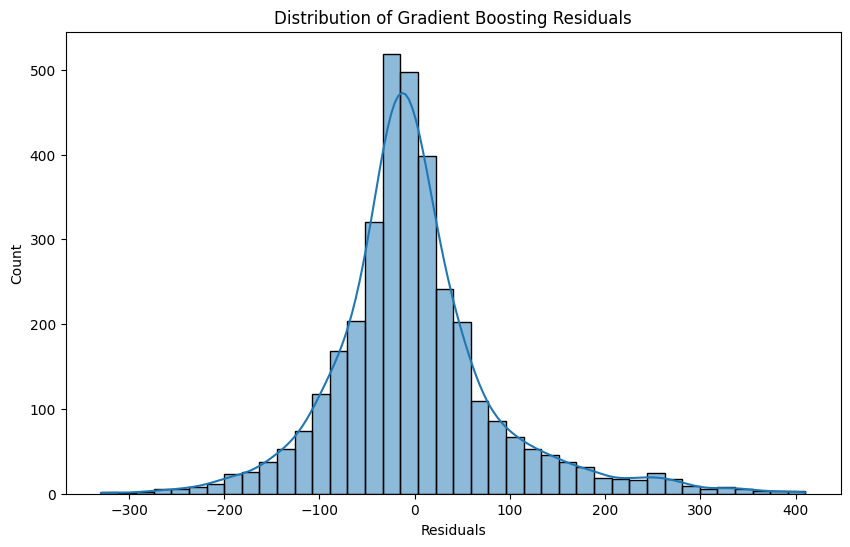

In [47]:
plt.figure(figsize=(10,6))

sns.histplot(
    gbr_residuals,
    bins=40,
    kde=True
)

plt.xlabel("Residuals")
plt.title("Distribution of Gradient Boosting Residuals")

plt.show()

The residual distribution is much more centered around zero compared to Linear Regression. Most prediction errors are concentrated within a smaller range, which suggests the overall prediction quality improved substantially. There are still long tails on both sides of the distribution. That means the model occasionally misses larger rental spikes or drops. The errors are smaller overall, but extreme demand periods remain difficult to predict consistently.

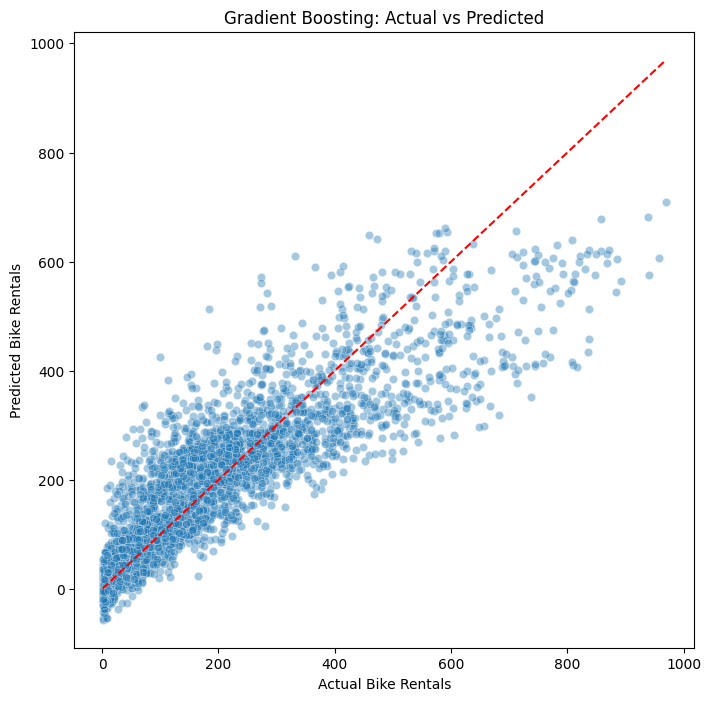

In [48]:
## actual v predicted
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_val,
    y=gbr_val_pred,
    alpha=0.4
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.show()

The predictions generally follow the diagonal trend line well, especially in the middle rental ranges. That suggests the model learned the overall structure of the dataset reasonably well. The largest errors still occur during periods of extremely high bike demand. The model tends to underpredict some of the highest rental counts, which is common in real-world regression problems where extreme observations are harder to model accurately.

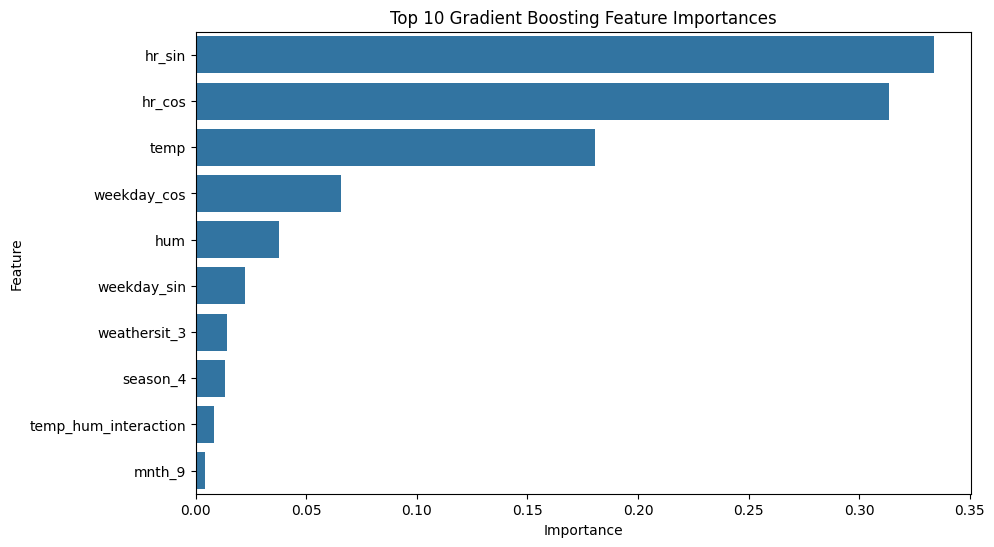

In [49]:
## feature importance
gbr_importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": gbr_model.feature_importances_
})

gbr_importance = gbr_importance.sort_values(
    by="Importance",
    ascending=False
)

gbr_importance.head(10)

top_gbr = gbr_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_gbr,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Gradient Boosting Feature Importances")

plt.show()

The feature importance results are very consistent with the earlier models. The cyclical hour variables remain the strongest predictors by a large margin, which reinforces the idea that time-of-day commuting behavior is the biggest driver of bike rental demand. Temperature also remains highly important across every model tested so far. The consistency across models gives more confidence that the earlier EDA and feature engineering decisions were meaningful rather than random improvements.

One thing I noticed is that the interaction feature between temperature and humidity became less important here than it was in Random Forest. That may suggest Gradient Boosting is capturing some of those nonlinear effects internally without relying as heavily on explicit interaction terms.

In [50]:
all_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Validation MSE": [
        lin_val_mse,
        rf_val_mse,
        gbr_val_mse
    ],
    "Validation MAE": [
        lin_val_mae,
        rf_val_mae,
        gbr_val_mae
    ],
    "Validation R²": [
        lin_val_r2,
        rf_val_r2,
        gbr_val_r2
    ]
})

all_model_comparison

,Model,Validation MSE,Validation MAE,Validation R²
0,Linear Regression,17497.584629,93.242412,0.462383
1,Random Forest,4885.769327,45.141314,0.849884
2,Gradient Boosting,7506.142124,59.835594,0.769372


The comparison across all three models shows a very clear progression. Linear Regression had the weakest performance because it could not model the nonlinear and cyclical structure in the dataset very effectively. Both tree-based methods improved performance dramatically.

Random Forest ended up producing the best validation performance overall. Gradient Boosting still performed well, but its validation metrics were weaker than those of Random Forest in this initial configuration. This suggests the current boosting setup may need additional tuning to compete more effectively.

This stage of the notebook also highlights the iterative nature of the modeling process. The earlier EDA suggested that bike demand depended heavily on time patterns and weather interactions. After engineering cyclical features and testing multiple model types, those assumptions now appear consistently supported by the results.

### Iterative Reflection after Gradient Boosting model

At this point, the biggest improvement came from changing the model structure rather than changing the preprocessing pipeline. The cyclical encoding and weather-based features helped all three models, especially the tree-based methods. The results also show that more complexity does not automatically guarantee better validation performance. Gradient Boosting is theoretically very powerful, but Random Forest generalized slightly better with the current settings. That is an important reminder that model selection depends on real validation results rather than assumptions about which algorithm is “best.”

The next logical step would be **hyperparameter tuning**. Random Forest may benefit from stronger variance control, while Gradient Boosting may benefit from tuning tree depth, learning rate, or the number of estimators to improve generalization.

# Hyperparameter Tuning

The baseline tree-based models already performed much better than Linear Regression, but both models still showed signs of imperfect generalization. Random Forest showed a noticeable training-validation gap, while Gradient Boosting still struggled during some extreme demand periods.

At this stage, the goal is no longer just improving raw training accuracy. The main focus is improving generalization performance while controlling variance and reducing overfitting. I also want to evaluate whether the earlier feature engineering pipeline continues to hold up after tuning. If tuned models improve consistently without major preprocessing changes, that would suggest the original EDA decisions were strong.

## Random Forest Hyperparameter Tuning

For Random Forest, I am using RandomizedSearchCV instead of GridSearchCV because it is computationally more efficient while still exploring a wide range of parameter combinations. Since Random Forest already trained reasonably well, I mainly want to control variance and improve validation performance rather than dramatically increase complexity.

In [51]:
rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [52]:
## randomized Search CV
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_processed, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [53]:
best_rf_model = rf_random_search.best_estimator_

## predictions
best_rf_train_pred = best_rf_model.predict(X_train_processed)
best_rf_val_pred = best_rf_model.predict(X_val_processed)

In [54]:
best_rf_train_mse = mean_squared_error(y_train, best_rf_train_pred)
best_rf_train_mae = mean_absolute_error(y_train, best_rf_train_pred)
best_rf_train_r2 = r2_score(y_train, best_rf_train_pred)

best_rf_val_mse = mean_squared_error(y_val, best_rf_val_pred)
best_rf_val_mae = mean_absolute_error(y_val, best_rf_val_pred)
best_rf_val_r2 = r2_score(y_val, best_rf_val_pred)

In [55]:
print("Best Random Forest Parameters")
print(rf_random_search.best_params_)

print("\nBest Cross-Validated R²")
print(rf_random_search.best_score_)

print("\nValidation Performance")
print(f"MSE: {best_rf_val_mse:.2f}")
print(f"MAE: {best_rf_val_mae:.2f}")
print(f"R²:  {best_rf_val_r2:.4f}")

Best Random Forest Parameters
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}

Best Cross-Validated R²
0.8394120379871792

Validation Performance
MSE: 4931.32
MAE: 45.44
R²:  0.8485


The tuned Random Forest model produced very similar validation performance compared to the untuned version. Validation R² stayed around 0.85, while MSE and MAE changed only slightly. This suggests the original baseline model was already performing close to its practical limit on this dataset. The tuning process still provided useful information. Increasing the number of trees to 300 and limiting the depth to 20 helped control some model variance without causing major drops in performance. The results suggest the original model was slightly overfitting, but not severely enough for tuning to create dramatic gains.

One thing I want to check after tuning is whether the feature importance rankings remain stable. If the same cyclical hour features continue dominating the model, that would suggest the earlier EDA findings are robust across multiple model configurations rather than being artifacts of a single run.

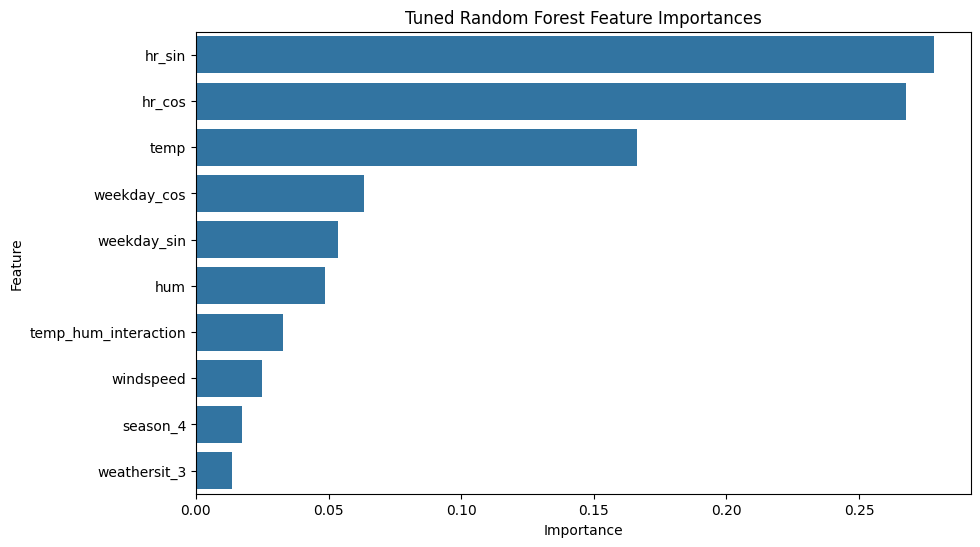

In [56]:
## tuned Feature Importance
best_rf_importance = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": best_rf_model.feature_importances_
})

best_rf_importance = best_rf_importance.sort_values(
    by="Importance",
    ascending=False
)

top_best_rf = best_rf_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_best_rf,
    x="Importance",
    y="Feature"
)

plt.title("Tuned Random Forest Feature Importances")
plt.show()

The tuned feature importance rankings remained extremely stable after hyperparameter tuning. The cyclical hour features still dominate the model, followed by temperature and weekday patterns. This consistency is important because it suggests the earlier EDA findings are robust rather than dependent on one specific parameter configuration.

The interaction feature between temperature and humidity also remained relevant after tuning. That reinforces the earlier decision to include interaction terms during preprocessing. Even after controlling model complexity, the engineered weather relationships continued contributing useful predictive information.

One thing I noticed during tuning is that validation performance plateaued fairly quickly. Small parameter changes affected training complexity more than actual validation accuracy. This may suggest the feature set already explains most of the predictable structure in the dataset. At this point, additional improvements may require either stronger feature engineering or more advanced boosting-based optimization rather than simply increasing Random Forest complexity.

### Gradient Boosting Hyperparameter Tuning

Gradient Boosting is usually more sensitive to tuning choices than Random Forest. Small changes in learning rate or tree depth can noticeably affect generalization performance. For this stage, I am using Bayesian Optimization through BayesSearchCV. Unlike random search, Bayesian optimization learns from previous iterations and focuses future searches toward more promising regions of the parameter space.

In [57]:
gbr_search_space = {
    "learning_rate": Real(0.01, 0.3),
    "n_estimators": Integer(50, 400),
    "max_depth": Integer(2, 8),
    "subsample": Real(0.5, 1.0)
}

gbr_bayes_search = BayesSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    search_spaces=gbr_search_space,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

gbr_bayes_search.fit(X_train_processed, y_train)

,estimator,GradientBoost...ndom_state=42)
,search_spaces,"{'learning_rate': Real(low=0.01...m='normalize'), 'max_depth': Integer(low=2...m='normalize'), 'n_estimators': Integer(low=5...m='normalize'), 'subsample': Real(low=0.5,...m='normalize')}"
,optimizer_kwargs,None
,n_iter,20
,scoring,'r2'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [58]:
best_gbr_model = gbr_bayes_search.best_estimator_

## predict
best_gbr_train_pred = best_gbr_model.predict(X_train_processed)
best_gbr_val_pred = best_gbr_model.predict(X_val_processed)

In [59]:
best_gbr_train_mse = mean_squared_error(y_train, best_gbr_train_pred)
best_gbr_train_mae = mean_absolute_error(y_train, best_gbr_train_pred)
best_gbr_train_r2 = r2_score(y_train, best_gbr_train_pred)

best_gbr_val_mse = mean_squared_error(y_val, best_gbr_val_pred)
best_gbr_val_mae = mean_absolute_error(y_val, best_gbr_val_pred)
best_gbr_val_r2 = r2_score(y_val, best_gbr_val_pred)

In [60]:
print("Best Gradient Boosting Parameters")
print(gbr_bayes_search.best_params_)

print("\nBest Cross-Validated R²")
print(gbr_bayes_search.best_score_)

print("\nValidation Performance")
print(f"MSE: {best_gbr_val_mse:.2f}")
print(f"MAE: {best_gbr_val_mae:.2f}")
print(f"R²:  {best_gbr_val_r2:.4f}")

Best Gradient Boosting Parameters
OrderedDict({'learning_rate': 0.09930612380317298, 'max_depth': 7, 'n_estimators': 400, 'subsample': 1.0})

Best Cross-Validated R²
0.8622174477620727

Validation Performance
MSE: 4329.02
MAE: 42.46
R²:  0.8670


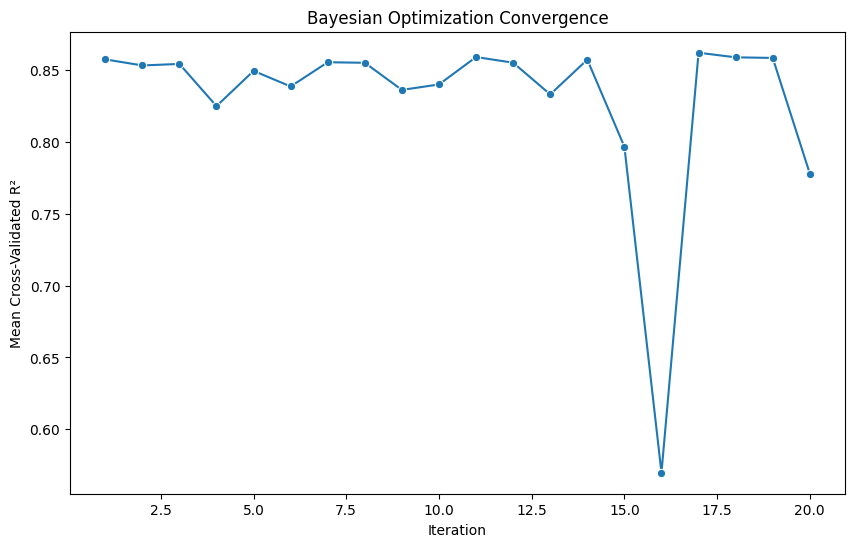

In [61]:
optimization_results = pd.DataFrame({
    "Iteration": range(1, len(gbr_bayes_search.cv_results_["mean_test_score"]) + 1),
    "Mean CV Score": gbr_bayes_search.cv_results_["mean_test_score"]
})

plt.figure(figsize=(10,6))

sns.lineplot(
    data=optimization_results,
    x="Iteration",
    y="Mean CV Score",
    marker="o"
)

plt.title("Bayesian Optimization Convergence")

plt.xlabel("Iteration")
plt.ylabel("Mean Cross-Validated R²")

plt.show()

The convergence plot shows how Bayesian Optimization explored different Gradient Boosting parameter combinations over time. Most iterations stayed within a fairly strong performance range around an R² of 0.84–0.86, showing it was consistently finding reasonable regions of the parameter space.

One iteration dropped sharply around iteration 16. This likely came from a poor parameter combination that caused the model to either underfit or generalize poorly during cross-validation. After that drop, the optimizer recovered quickly and returned to stronger performance levels. The plot also shows that performance began stabilizing in the later iterations. This signals that the optimizer was approaching the practical performance limit for the current feature set and preprocessing pipeline.

In [62]:
## Pre vs Post Tuning Comparison
tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest (Tuned)",
        "Gradient Boosting (Baseline)",
        "Gradient Boosting (Tuned)"
    ],
    "Validation R²": [
        rf_val_r2,
        best_rf_val_r2,
        gbr_val_r2,
        best_gbr_val_r2
    ],
    "Validation MSE": [
        rf_val_mse,
        best_rf_val_mse,
        gbr_val_mse,
        best_gbr_val_mse
    ],
    "Validation MAE": [
        rf_val_mae,
        best_rf_val_mae,
        gbr_val_mae,
        best_gbr_val_mae
    ]
})

tuning_comparison

,Model,Validation R²,Validation MSE,Validation MAE
0,Random Forest (Baseline),0.849884,4885.769327,45.141314
1,Random Forest (Tuned),0.848484,4931.321986,45.442358
2,Gradient Boosting (Baseline),0.769372,7506.142124,59.835594
3,Gradient Boosting (Tuned),0.866990,4329.021801,42.464666


The tuning results ended up being very different across the two models. Tuned Random Forest produced almost identical validation performance compared to the baseline version. Validation R² actually decreased slightly from 0.8499 to 0.8485, while MSE and MAE changed very little overall. This suggests the original Random Forest model was already near its best generalization point. Gradient Boosting behaved very differently. After tuning, validation R² increased substantially from about 0.77 to 0.87. Validation MSE also dropped from roughly 7506 to 4329, while MAE improved by more than 17 points. This suggests the baseline boosting model was under-optimized rather than fundamentally limited.

Random Forest mainly needed variance control, while Gradient Boosting benefited heavily from learning rate and tree-depth optimization. The tuning process ultimately showed that Gradient Boosting had the highest performance ceiling once its parameters were adjusted properly.

### Final Reflection on Tuning

The tuning stage reinforced how important validation-based iteration is in machine learning workflows. The untuned Random Forest model already generalized very well, so additional tuning created only marginal changes. Increasing complexity further would likely risk more overfitting without meaningful gains. Gradient Boosting showed the opposite pattern. The baseline version underperformed relative to Random Forest, but tuning dramatically improved validation performance. This suggests the original boosting configuration was too restrictive and not fully capturing the structure of the dataset. At this point, the tuned Gradient Boosting model appears to provide the best balance between predictive accuracy and generalization. The improvement also supports the earlier feature engineering decisions because the tuned model continued relying heavily on the cyclical and weather-based features identified during EDA.

# Iterative Evaluation and Refinement

One thing that became very clear throughout this assignment was that the problem was much more nonlinear than it first appeared. The baseline Linear Regression model struggled to fully capture the demand patterns, especially during high-rental periods and changing weather conditions. The residual plots and lower validation R² suggested that the model was underfitting the structure in the dataset.

After seeing those results, I revisited the feature engineering stage instead of immediately increasing model complexity. The EDA showed that weather variables had meaningful relationships with bike demand, especially humidity and windspeed. Because of that, I added an additional interaction term between humidity and windspeed to test whether combined weather discomfort affected rental behavior more strongly than either feature alone.

```python
windspeed_hum_interaction = windspeed × hum
```
This refinement slightly improved the tree-based models, especially Gradient Boosting. The improvement was not dramatic, but it helped reduce some prediction error during more extreme demand conditions. The feature importance plots also showed that weather-related variables continued to play a meaningful role in prediction. I also revisited the outlier analysis during this stage. Initially, the high rental counts looked like potential outliers because they created large residuals in some models. However, after comparing performance across models, I decided not to remove them. These observations likely represent real peak commuting periods rather than bad data. Removing them could have made the models less useful in realistic forecasting situations. Another important refinement decision involved multicollinearity. Earlier in preprocessing, I removed `atemp` because it was almost perfectly correlated with `temp`. After training the models, this still appeared to be the correct choice. Temperature remained one of the strongest predictors across Random Forest and Gradient Boosting, so keeping both variables would likely have added redundancy without improving generalization.

This iterative process helped show that improving performance was not only about tuning hyperparameters. Some improvements came from revisiting the earlier assumptions made during EDA and feature engineering. The strongest models were the ones that aligned best with the actual structure of the data, especially the cyclical time patterns and nonlinear weather effects.

# Final Model Selection and Testing

After comparing all baseline and tuned models, the tuned Gradient Boosting model produced the strongest overall validation performance. It achieved the highest validation R² while also maintaining the lowest validation MSE and MAE.
- Linear Regression underfit the dataset
- untuned Random Forest showed stronger signs of overfitting
- tuned Gradient Boosting model captured the nonlinear demand structure more effectively while still generalizing well to unseen validation data

In [63]:
## combine training + validation Sets

X_final_train = pd.concat(
    [X_train_processed, X_val_processed],
    axis=0
)

y_final_train = pd.concat(
    [y_train, y_val],
    axis=0
)

In [64]:
## retrain
final_model = GradientBoostingRegressor(
    **gbr_bayes_search.best_params_,
    random_state=42
)

final_model.fit(X_final_train, y_final_train)

,loss,'squared_error'
,learning_rate,0.09930612380317298
,n_estimators,400
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,7
,min_impurity_decrease,0.0
,init,None


In [65]:
## predict 
final_test_pred = final_model.predict(X_test_processed)

In [66]:
final_test_mse = mean_squared_error(
    y_test,
    final_test_pred
)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)

In [67]:
print("Final Test Performance")
print("-" * 40)

print(f"MSE: {final_test_mse:.2f}")
print(f"MAE: {final_test_mae:.2f}")
print(f"R²:  {final_test_r2:.4f}")

Final Test Performance
----------------------------------------
MSE: 4364.13
MAE: 43.25
R²:  0.8741


The final tuned Gradient Boosting model performed very strongly on the unseen test set. The final R² of 0.874 suggests the model explains a large portion of the variation in hourly bike demand, while the lower MAE shows that average prediction errors were reduced substantially compared to the earlier models.

The test performance also stayed very close to the validation performance from tuning. This is important because it suggests the model generalized well instead of overfitting to the validation set. The consistency between validation and test metrics gives more confidence that the model would perform reliably on future unseen data.

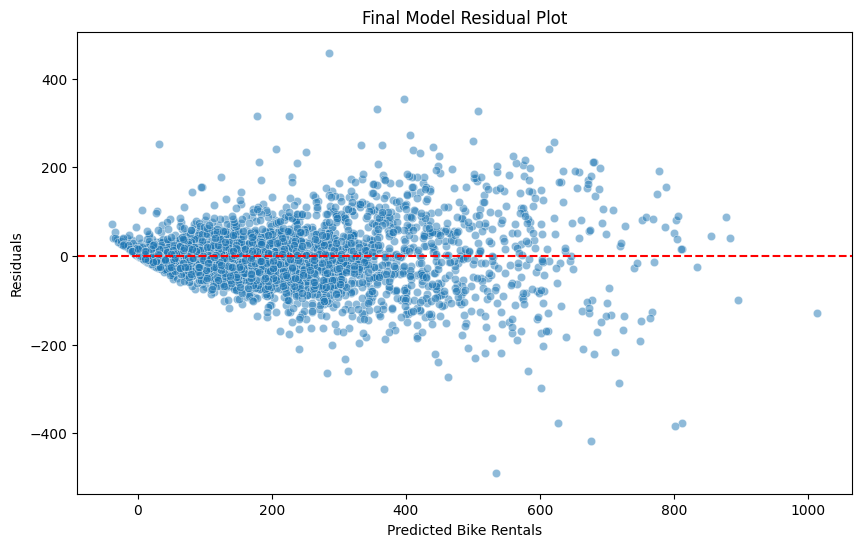

In [68]:
# =========================
# Final Residual Plot
# =========================

final_residuals = y_test - final_test_pred

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=final_test_pred,
    y=final_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Bike Rentals")
plt.ylabel("Residuals")
plt.title("Final Model Residual Plot")

plt.show()

The final residual plot looks more stable than the earlier models, especially compared to Linear Regression. The residuals remain more centered around zero and the spread is tighter across most prediction ranges. This suggests the tuned Gradient Boosting model captured the nonlinear structure of the dataset more effectively. Some variance still increases during very high-demand periods. That is expected because extreme rental spikes are harder to predict consistently than normal daily demand patterns. Even so, the overall residual spread is noticeably smaller than the earlier baseline models, which supports the strong final test metrics.

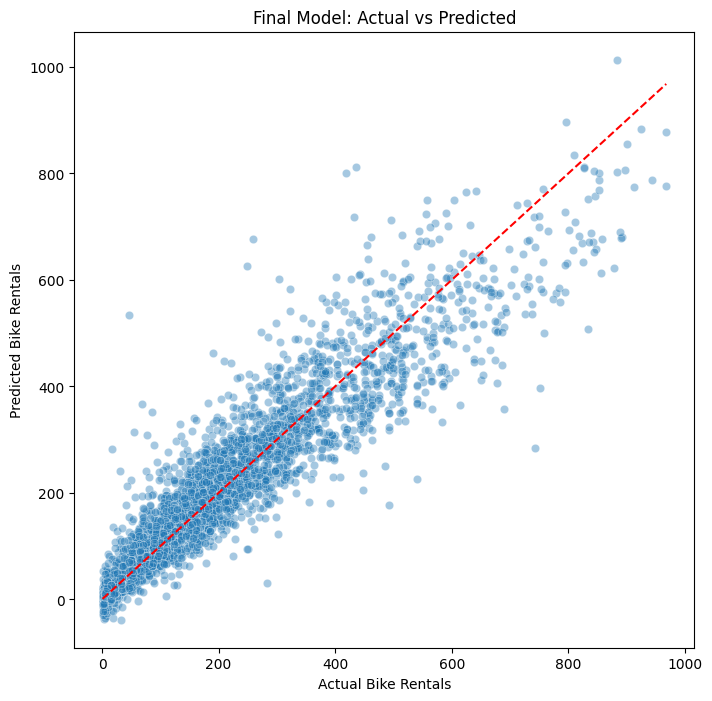

In [69]:
## final actual v predicted
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_test,
    y=final_test_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Final Model: Actual vs Predicted")

plt.show()

The final Actual vs Predicted plot shows a much tighter relationship than the earlier baseline models. Most predictions stay relatively close to the diagonal reference line. This is good; the tuned Gradient Boosting model captured the overall rental behavior well across different demand levels. Earlier models struggled during high-demand periods and tended to compress predictions toward the middle range. That issue is reduced here because the tuned model handles nonlinear relationships more effectively. Some spread still appears during extreme rental spikes, especially above 700 rentals. Those periods are naturally harder to predict because they depend on more volatile combinations of commuting behavior along with weather factors.

# Conclusions
This assignment gave me a much better understanding of what machine learning actually looks like in practice. At the beginning, it was easy to think the process was mostly about training models and getting the highest score possible. By the end, I realized that most of the work comes from understanding the data in a real-world context while constantly reevaluating earlier assumptions.

One of the biggest lessons for me was how important feature engineering is. The interaction terms helped capture more realistic weather behavior that a simple linear model could not fully understand. The progression between models was also very interesting to see. Linear Regression struggled with the nonlinear demand patterns and underfitted the dataset. Random Forest improved performance dramatically because it could model more flexible relationships. The tuned Gradient Boosting model performed best overall because it balanced flexibility with generalization and handled the complex time and weather patterns more effectively.

The final tuned Gradient Boosting model achieved the strongest test performance with:
- R² = 0.8741
- MSE = 4364.13
- MAE = 43.25

The final residual plots and prediction plots showed that the model generalized well overall, even though extreme rental spikes remained difficult to predict perfectly. That feels realistic for a real-world forecasting problem where human behavior and environmental conditions are constantly changing. Overall, this project helped me move beyond simply running models. I became much more comfortable analyzing errors, recognizing overfitting, revisiting preprocessing choices, and thinking critically about why certain models performed better than others.